In [1]:
import pandas as pd
import numpy as np

In [2]:
X_final = pd.read_csv("../data/processed/X_final.csv")
y_final = pd.read_csv("../data/processed/y_final.csv").squeeze()

print(X_final.shape)
print(y_final.shape)

(50000, 162)
(50000,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

print(X_train.shape)
print(X_test.shape)

(40000, 162)
(10000, 162)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

In [5]:
print(X_final.isnull().sum().sum())

4664


In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_final_imputed = imputer.fit_transform(X_final)

# Convert back to DataFrame
X_final = pd.DataFrame(X_final_imputed, columns=X_final.columns)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      2500
         Low       0.52      1.00      0.69      5226
      Medium       0.00      0.00      0.00      2274

    accuracy                           0.52     10000
   macro avg       0.17      0.33      0.23     10000
weighted avg       0.27      0.52      0.36     10000



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [10]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

        High       0.78      0.75      0.77      2500
         Low       0.87      0.89      0.88      5226
      Medium       0.62      0.61      0.61      2274

    accuracy                           0.79     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.79      0.79      0.79     10000



In [11]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
              precision    recall  f1-score   support

        High       0.75      0.60      0.67      2500
         Low       0.74      0.94      0.83      5226
      Medium       0.63      0.37      0.46      2274

    accuracy                           0.72     10000
   macro avg       0.70      0.64      0.65     10000
weighted avg       0.71      0.72      0.70     10000



In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Use model's class order
y_test_bin = label_binarize(y_test, classes=gb.classes_)
y_prob_gb = gb.predict_proba(X_test)

roc_score = roc_auc_score(y_test_bin, y_prob_gb, multi_class="ovr")

print("Corrected Gradient Boosting ROC-AUC:", roc_score)

Corrected Gradient Boosting ROC-AUC: 0.8763311302023213


In [15]:
# Get predicted probabilities
risk_probabilities = gb.predict_proba(X_test)

# Convert to DataFrame
risk_df = pd.DataFrame(
    risk_probabilities,
    columns=gb.classes_
)

risk_df.head()

,High,Low,Medium
0,0.230263,0.705651,0.064086
1,0.304930,0.476487,0.218583
2,0.132143,0.368111,0.499746
3,0.042833,0.802093,0.155074
4,0.474831,0.179378,0.345791


In [16]:
# Risk score = probability of HIGH class × 100
risk_df["risk_score"] = risk_df["High"] * 100

risk_df.head()

,High,Low,Medium,risk_score
0,0.230263,0.705651,0.064086,23.026282
1,0.304930,0.476487,0.218583,30.493012
2,0.132143,0.368111,0.499746,13.214262
3,0.042833,0.802093,0.155074,4.283260
4,0.474831,0.179378,0.345791,47.483104


In [17]:
def score_band(score):
    if score < 33:
        return "Low"
    elif score < 66:
        return "Medium"
    else:
        return "High"

risk_df["risk_band"] = risk_df["risk_score"].apply(score_band)

risk_df.head()

,High,Low,Medium,risk_score,risk_band
0,0.230263,0.705651,0.064086,23.026282,Low
1,0.304930,0.476487,0.218583,30.493012,Low
2,0.132143,0.368111,0.499746,13.214262,Low
3,0.042833,0.802093,0.155074,4.283260,Low
4,0.474831,0.179378,0.345791,47.483104,Medium


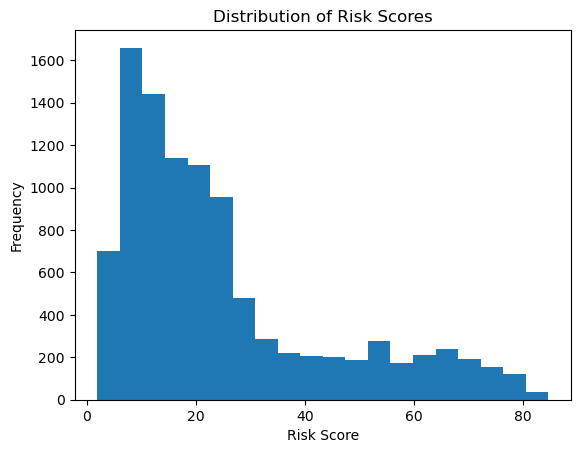

In [18]:
import matplotlib.pyplot as plt

plt.hist(risk_df["risk_score"], bins=20)
plt.title("Distribution of Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

In [19]:
print("Max risk score:", risk_df["risk_score"].max())
print("Min risk score:", risk_df["risk_score"].min())
print("Average risk score:", risk_df["risk_score"].mean())

Max risk score: 84.57193645655119
Min risk score: 1.9532269726085512
Average risk score: 24.91022518452252


In [20]:
risk_df["predicted_class"] = gb.predict(X_test)
risk_df["confidence"] = risk_df[gb.classes_].max(axis=1) * 100

risk_df.head()

,High,Low,Medium,risk_score,risk_band,predicted_class,confidence
0,0.230263,0.705651,0.064086,23.026282,Low,Low,70.565103
1,0.304930,0.476487,0.218583,30.493012,Low,Low,47.648719
2,0.132143,0.368111,0.499746,13.214262,Low,Medium,49.974641
3,0.042833,0.802093,0.155074,4.283260,Low,Low,80.209329
4,0.474831,0.179378,0.345791,47.483104,Medium,High,47.483104


In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": gb.feature_importances_
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)

feature_importance.head(10)

,feature,importance
103,Crop_Moong(Green Gram),0.072264
140,Crop_Sesamum,0.068813
154,Crop_Urad,0.067705
99,Crop_Maize,0.053761
133,Crop_Rice,0.050813
39,Season_Whole Year,0.041344
144,Crop_Sugarcane,0.035660
125,Crop_Potato,0.033888
107,Crop_Onion,0.032592
1,Area,0.032162


In [24]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# Compute balanced sample weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Train weighted Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weights)

# Predictions
y_pred_gb = gb.predict(X_test)

print("Weighted Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

Weighted Gradient Boosting
              precision    recall  f1-score   support

        High       0.66      0.71      0.68      2500
         Low       0.90      0.69      0.78      5226
      Medium       0.47      0.69      0.56      2274

    accuracy                           0.70     10000
   macro avg       0.68      0.70      0.68     10000
weighted avg       0.75      0.70      0.71     10000



In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=gb.classes_)
y_prob_gb = gb.predict_proba(X_test)

roc_score = roc_auc_score(y_test_bin, y_prob_gb, multi_class="ovr")

print("Weighted ROC-AUC:", roc_score)

Weighted ROC-AUC: 0.8745791731660056


In [26]:
print(gb.classes_)

['High' 'Low' 'Medium']


In [27]:
# Predict probabilities
y_prob = gb.predict_proba(X_test)

# Convert to DataFrame using correct class order
prob_df = pd.DataFrame(y_prob, columns=gb.classes_)

prob_df.head()

,High,Low,Medium
0,0.421556,0.485742,0.092701
1,0.438307,0.268776,0.292917
2,0.140030,0.204946,0.655024
3,0.047617,0.718605,0.233778
4,0.438229,0.133072,0.428699


In [28]:
risk_score = (
    prob_df["Low"] * 30 +
    prob_df["Medium"] * 60 +
    prob_df["High"] * 100
)

risk_score = risk_score.round(2)

print("Average Risk Score:", risk_score.mean())
print(risk_score.head())

Average Risk Score: 59.801157999999994
0    62.29
1    69.47
2    59.45
3    40.35
4    73.54
dtype: float64


In [29]:
def assign_zone(score):
    if score <= 30:
        return "Low"
    elif score <= 60:
        return "Moderate"
    elif score <= 80:
        return "High"
    else:
        return "Critical"

risk_zone = risk_score.apply(assign_zone)

print(risk_zone.value_counts())

High        4509
Moderate    4488
Critical    1003
Name: count, dtype: int64


In [30]:
results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = y_pred_gb
results["Risk_Score"] = risk_score.values
results["Risk_Zone"] = risk_zone.values

results.head()

,Crop_Year,Area,Year,AverageTemperature,State_Name_Andhra Pradesh,State_Name_Arunachal Pradesh,State_Name_Assam,State_Name_Bihar,State_Name_Chandigarh,State_Name_Chhattisgarh,...,Crop_Water Melon,Crop_Wheat,Crop_Yam,Crop_other fibres,Crop_other misc. pulses,Crop_other oilseeds,Actual,Predicted,Risk_Score,Risk_Zone
6517,2007.0,2.0,2007.0,24.649917,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,High,Low,62.29,High
18997,2002.0,3.0,2002.0,24.913000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Low,High,69.47,High
48268,2003.0,753.0,2003.0,24.649917,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Medium,Medium,59.45,Moderate
13058,2004.0,80131.0,2004.0,24.634583,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,Low,Low,40.35,Moderate
16170,2008.0,263.0,2008.0,24.406000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Medium,High,73.54,High


In [31]:
critical_cases = results[results["Risk_Zone"] == "Critical"]

print("Total Critical:", len(critical_cases))
print("Actual class breakdown in Critical:")
print(critical_cases["Actual"].value_counts())

Total Critical: 1003
Actual class breakdown in Critical:
Actual
High      857
Medium    112
Low        34
Name: count, dtype: int64


In [34]:
pip uninstall shap numpy pandas scipy numba llvmlite -y

Found existing installation: shap 0.50.0
Uninstalling shap-0.50.0:
  Successfully uninstalled shap-0.50.0
Found existing installation: numpy 2.4.2
Uninstalling numpy-2.4.2:
  Successfully uninstalled numpy-2.4.2
Found existing installation: pandas 3.0.1
Uninstalling pandas-3.0.1:
  Successfully uninstalled pandas-3.0.1
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: numba 0.64.0
Uninstalling numba-0.64.0:
  Successfully uninstalled numba-0.64.0
Found existing installation: llvmlite 0.46.0
Uninstalling llvmlite-0.46.0:
  Successfully uninstalled llvmlite-0.46.0
Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install numpy==1.26.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 6.7 MB/s  0:00:02m 6.8 MB/s eta 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires pandas<3,>=1.3.0, which is not installed.
statsmodels 0.14.0 requires pandas>=1.0, which is not installed.
statsmodels 0.14.0 requires scipy!=1.9.2,>=1.4, which is not installed.
bokeh 3.3.4 requires pandas>=1.2, which is not installed.
scikit-learn 1.2.2 requires scipy>=1.3.2, which is not installed.
panel 1.3.8 requires pandas>=1.2, which is not installed.
imbalanced-learn 0.11.0 requires scipy>=1.5.0, which is not installed.
scikit-image 0.22.0 requires scipy>=1.8, which is not installed.
hvplot 0.9.2 requires pandas, which is not installed.
altair 5.0.1 requires pandas>=0.18, which is not installed.
holoviews 1.18.3 requires pandas>=0.20.0, which is not installed.
jax 0.4.34 requires scipy

In [37]:
pip install pandas==2.1.4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 16.4 MB/s  0:00:01.6 MB/s eta 0:00:0102
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
statsmodels 0.14.0 requires scipy!=1.9.2,>=1.4, which is not installed.
datashader 0.16.0 requires numba, which is not installed.
datashader 0.16.0 requires scipy, which is not installed.
Note: you may need to restart the kernel to use updated packages.


In [38]:
pip install scipy==1.11.4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.7/29.7 MB 5.1 MB/s  0:00:05 eta 0:00:010:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
datashader 0.16.0 requires numba, which is not installed.
Note: you may need to restart the kernel to use updated packages.


In [39]:
pip install numba==0.59.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 9.0 MB/s  0:00:007.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 18.8 MB/s  0:00:01 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]━━━━━ 1/2 [numba]
Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install llvmlite==0.42.0

Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install shap==0.44.1

  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.8
    Uninstalling slicer-0.0.8:
      Successfully uninstalled slicer-0.0.8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]
Note: you may need to restart the kernel to use updated packages.


In [45]:
import numpy
import pandas
import scipy
import shap

In [48]:
type(gb)

sklearn.ensemble._gb.GradientBoostingClassifier

In [49]:
gb.n_classes_

3

In [50]:
explainer = shap.Explainer(gb.predict_proba, X_train)
shap_values = explainer(X_test)


PermutationExplainer explainer: 10001it [03:50, 41.83it/s]                      


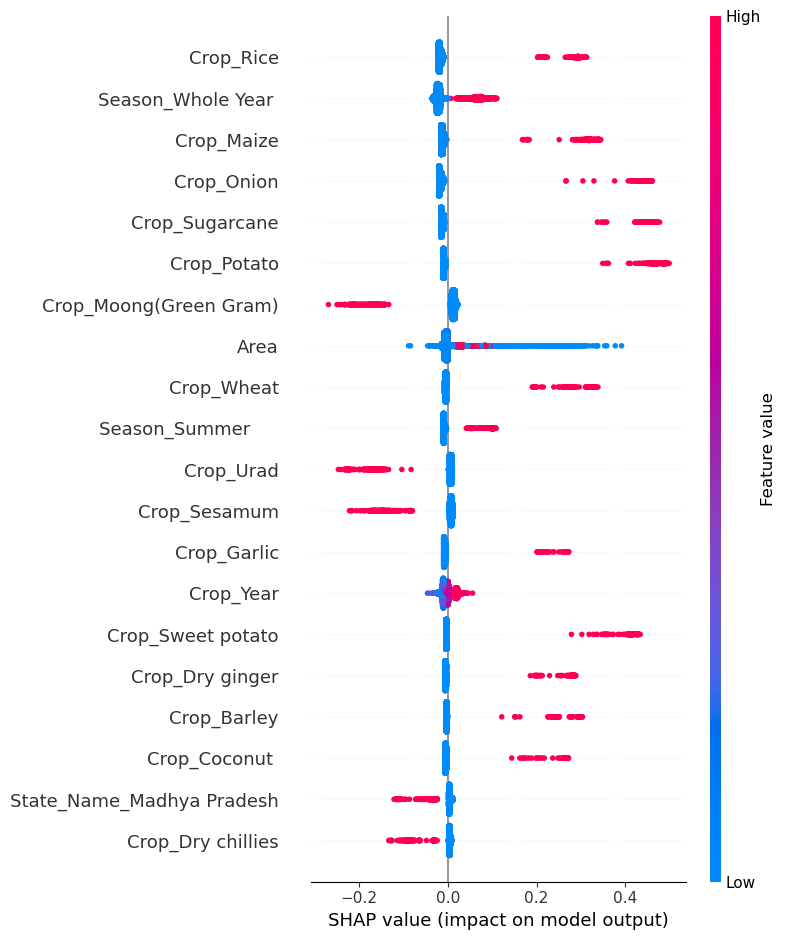

In [53]:

shap.summary_plot(shap_values[..., 1], X_test)

In [56]:
import shap

# If you want SHAP for probabilities:
explainer = shap.Explainer(gb.predict_proba, X_train)
shap_values = explainer(X_test)

PermutationExplainer explainer: 10001it [03:42, 42.80it/s]                      


In [58]:
# Get class index for "High"
class_index = gb.classes_.tolist().index("High")  # or "Critical" etc.

# Slice SHAP values for that class
shap_values_high = shap_values[:, :, class_index]

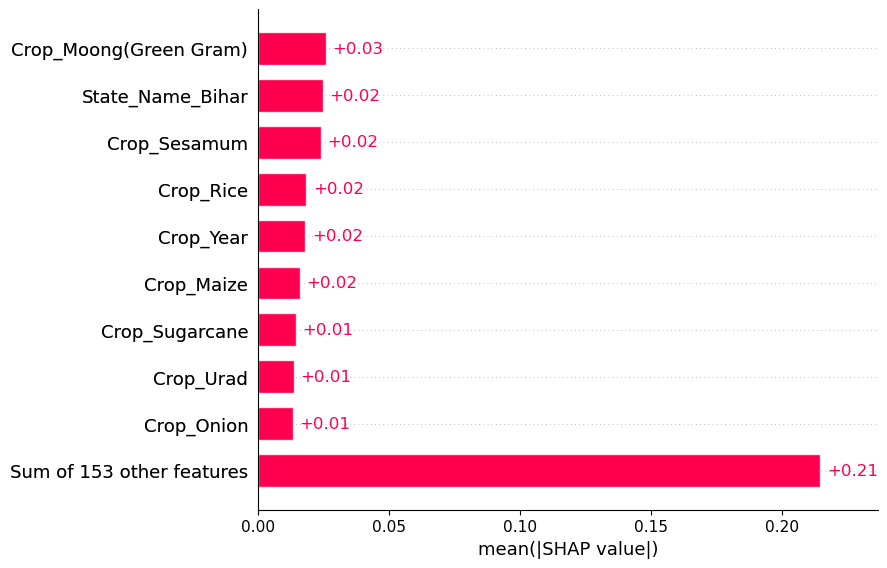

In [59]:
shap.plots.bar(shap_values_high)

In [60]:
import matplotlib.pyplot as plt
plt.savefig("shap_global_bar_high.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

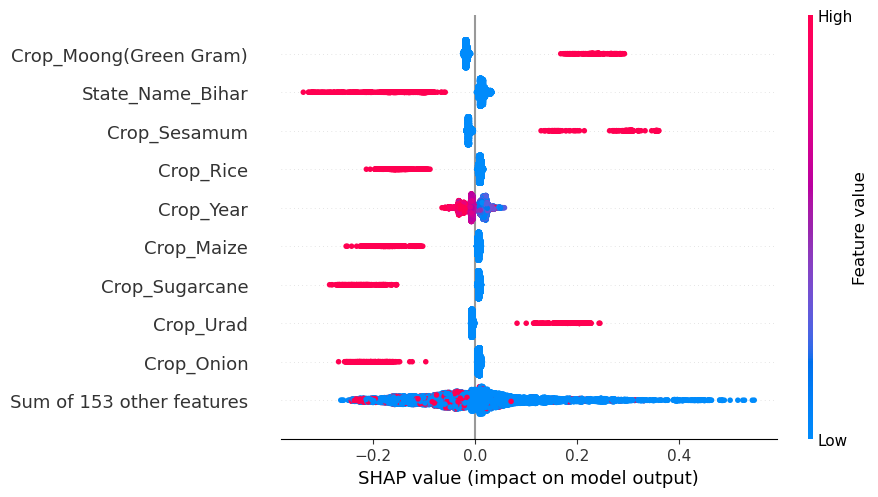

<Figure size 640x480 with 0 Axes>

In [61]:
shap.plots.beeswarm(shap_values_high)
plt.savefig("shap_beeswarm_high.png", dpi=300, bbox_inches='tight')

In [63]:
# Get index of critical sample in original dataset
critical_idx = results[results["Risk_Zone"] == "Critical"].index[0]

# Find the corresponding row in X_test
sample_index_in_test = X_test.index.get_loc(critical_idx)  # converts to 0-based index

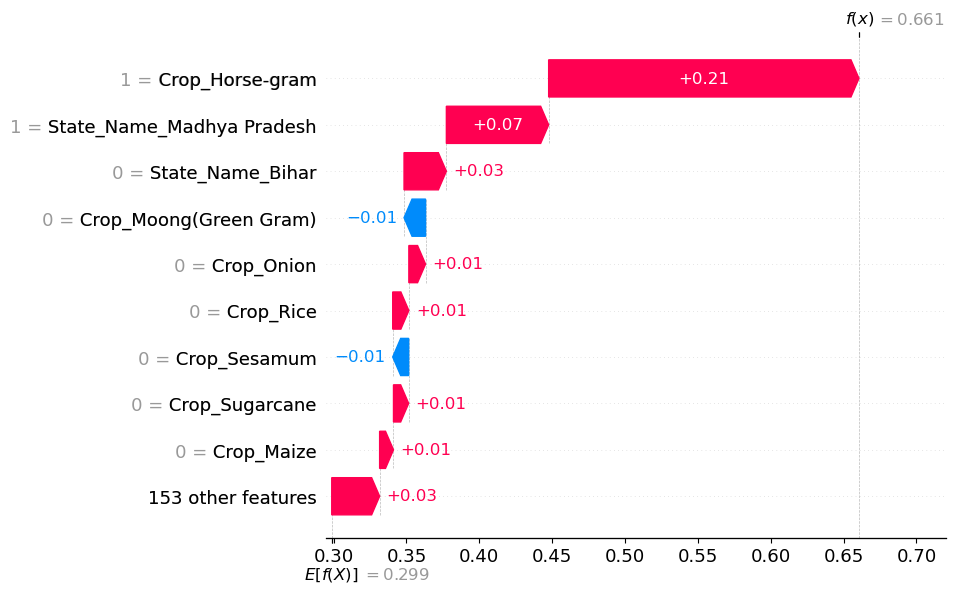

In [64]:
class_index = gb.classes_.tolist().index("High")  # or "Critical"

shap.plots.waterfall(shap_values[sample_index_in_test][:, class_index])

In [66]:
import joblib
joblib.dump(gb, "risk_model.pkl")

['risk_model.pkl']

In [84]:
import pandas as pd

# Use median values from training data as neutral baseline
base = X_train.median()

scenario_A = base.copy()
scenario_B = base.copy()
scenario_C = base.copy()

In [85]:
# Convert to single-row DataFrame
scenario_A = pd.DataFrame([scenario_A])
scenario_B = pd.DataFrame([scenario_B])
scenario_C = pd.DataFrame([scenario_C])

In [86]:
crop_cols = [col for col in X_train.columns if col.startswith("Crop_")]

scenario_A[crop_cols] = 0
scenario_B[crop_cols] = 0
scenario_C[crop_cols] = 0

In [87]:
scenario_A["Crop_Moong(Green Gram)"] = 1
scenario_B["Crop_Sesamum"] = 1
scenario_C["Crop_Rice"] = 1

In [88]:
scenarios = pd.concat([scenario_A, scenario_B, scenario_C])

In [89]:
probs = gb.predict_proba(scenarios)
prob_df = pd.DataFrame(probs, columns=gb.classes_)

risk_scores = (
    prob_df["Low"] * 30 +
    prob_df["Medium"] * 60 +
    prob_df["High"] * 100
)

print(prob_df)
print(risk_scores)

       High       Low    Medium
0  0.621890  0.091833  0.286278
1  0.716913  0.099756  0.183331
2  0.147732  0.608872  0.243396
0    82.120610
1    85.683839
2    47.643108
dtype: float64
